<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-01-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Practical Assignment - 04
### Assignments based on Supervised Learning - Regression and Classification algorithms

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** | 125M1H031  |
| **Student Name** |Shahid Momin |
| **Submission Date** |04-09-2026 |
</div>

### Section 1: Implememnt Linear Regression model to predict house prices based on various features
<!-- **Course Outcome: CO1** -->



## California Housing dataset

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('D:\CODES\Data Science\DATA\housing.csv')
df.head()

<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Shahid Momin\AppData\Local\Temp\ipykernel_20328\2807716770.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv('D:\CODES\Data Science\DATA\housing.csv')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [11]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean(), inplace=True)

C:\Users\Shahid Momin\AppData\Local\Temp\ipykernel_20328\626380549.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean(), inplace=True)


In [12]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [14]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [15]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [17]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(df[['ocean_proximity']])
df_final = pd.concat([df.drop('ocean_proximity', axis=1), pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['ocean_proximity']))], axis=1)
df_final.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.set_output(transform="pandas")
scaled_features = scaler.fit_transform(df_final.drop('median_house_value', axis=1))
df_final_scaled = pd.concat([scaled_features, df_final['median_house_value']], axis=1)
df_final_scaled.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,median_house_value
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.0,0.0,0.0,1.0,0.0,452600.0
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.0,0.0,0.0,1.0,0.0,358500.0
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.0,0.0,0.0,1.0,0.0,352100.0
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.0,0.0,0.0,1.0,0.0,341300.0
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.0,0.0,0.0,1.0,0.0,342200.0


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df_final_scaled.drop('median_house_value', axis=1)
y = df_final_scaled['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.6501438091346337


In [25]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("R-squared:", r2)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)

R-squared: 0.6501438091346337
Mean Squared Error: 4756895621.914481
Root Mean Squared Error: 68970.25171705901
Mean Absolute Error: 49950.072357992896


### Section 1: Implememnt Linear Regression model to predict car prices based on various features such as engine size, horsepower, curb, weight etc
<!-- **Course Outcome: CO1** -->

## Automobile dataset

In [26]:
df = pd.read_csv('D:\CODES\Data Science\DATA\Automobile_data.csv')
df.head()

<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Shahid Momin\AppData\Local\Temp\ipykernel_20328\746115866.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv('D:\CODES\Data Science\DATA\Automobile_data.csv')


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [27]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [29]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='str')

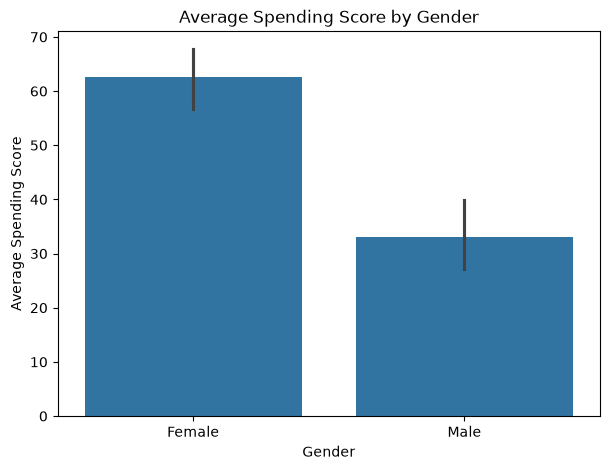

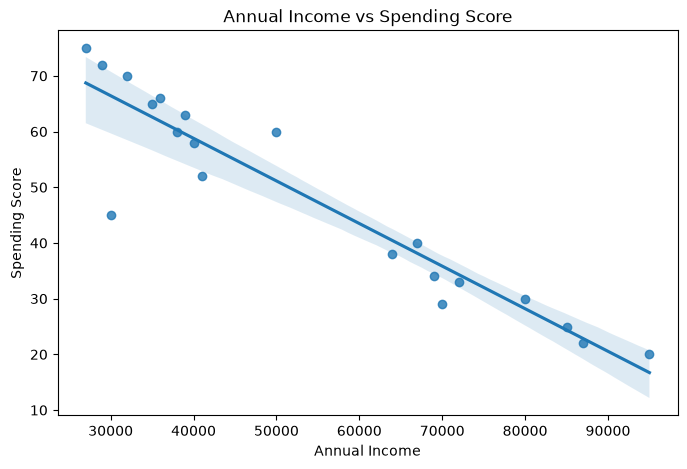

In [39]:
# vi. Annual Income vs Spending Score
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore"
)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

### Question

You are provided with a retail sales dataset containing product categories, unit prices, quantities sold, total sales, and regional information. Your task is to perform exploratory data analysis with the following objectives. (product_sales.csv)

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("D:\CODES\Data Science\DATA\product_sales - product_sales.csv")

print("Product Sales Dataset:")
print(df)

print("\nColumn Names:")
print(df.columns)

print("\nStatistical Summary:")
print(df.describe())

Product Sales Dataset:
    ProductID     Category Region  UnitPrice  QuantitySold  TotalSales  \
0         101  Electronics  North       1200            15       18000   
1         102      Fashion  South       1500             8       12000   
2         103  Electronics   West       1100            20       22000   
3         104         Home   East        900            18       16200   
4         105      Fashion  North       1300            12       15600   
5         106  Electronics  South       1400            10       14000   
6         107         Home   West        850            14       11900   
7         108      Fashion   East       1600             9       14400   
8         109  Electronics  North       1350            13       17550   
9         110      Fashion  South       1550            11       17050   
10        111         Home   East        920            16       14720   
11        112  Electronics   West       1250            19       23750   
12        113  

<>:6: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:6: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Shahid Momin\AppData\Local\Temp\ipykernel_18676\2623659363.py:6: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv("D:\CODES\Data Science\DATA\product_sales - product_sales.csv")


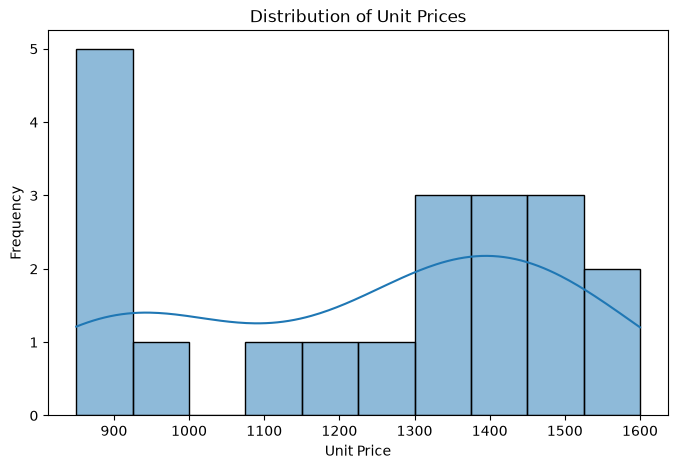

In [41]:
plt.figure(figsize=(8, 5))

sns.histplot(df["UnitPrice"], bins=10, kde=True)

plt.title("Distribution of Unit Prices")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

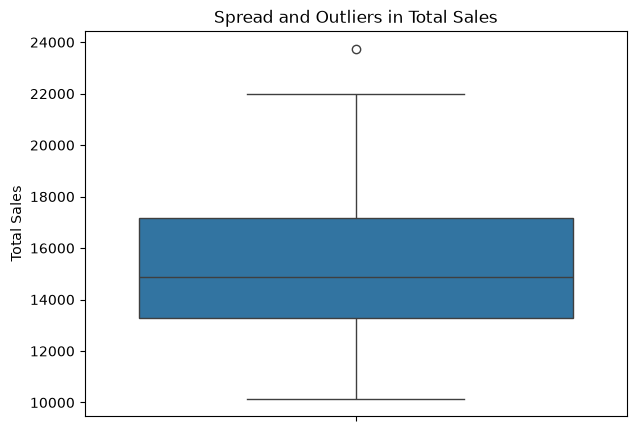

In [42]:
plt.figure(figsize=(7, 5))

sns.boxplot(y=df["TotalSales"])

plt.title("Spread and Outliers in Total Sales")
plt.ylabel("Total Sales")

plt.show()

Total Sales by Category:
Category
Electronics    129620
Fashion         95300
Home            84480
Name: TotalSales, dtype: int64


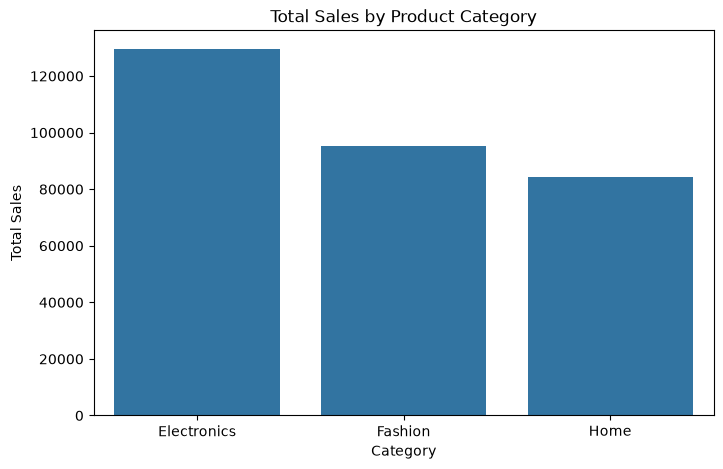

In [43]:
category_sales = df.groupby("Category")["TotalSales"].sum().sort_values(
    ascending=False
)

print("Total Sales by Category:")
print(category_sales)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

Total Sales by Region:
Region
West     82080
South    77070
North    76430
East     73820
Name: TotalSales, dtype: int64


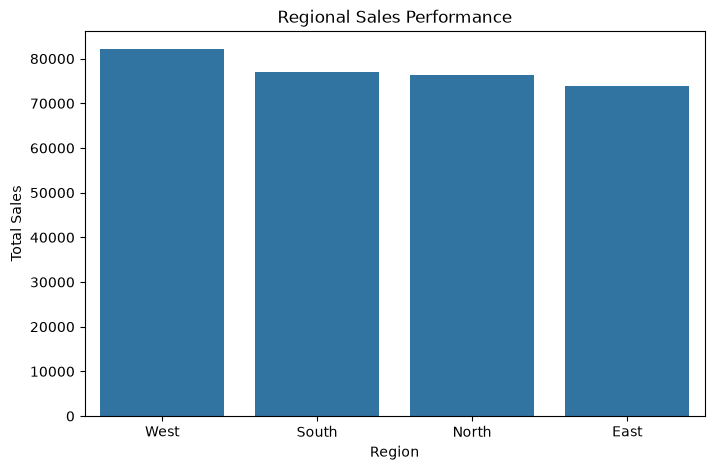

In [44]:
regional_sales = df.groupby("Region")["TotalSales"].sum().sort_values(
    ascending=False
)

print("Total Sales by Region:")
print(regional_sales)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=regional_sales.index,
    y=regional_sales.values
)

plt.title("Regional Sales Performance")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

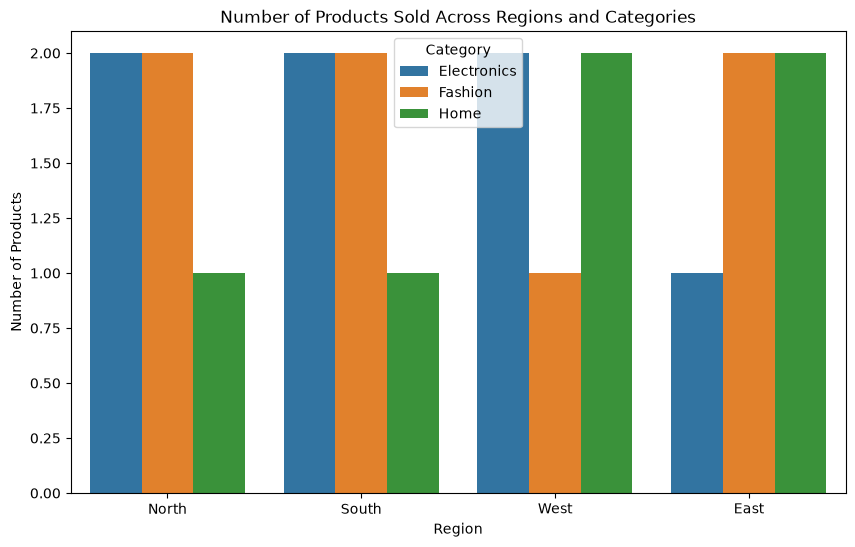

In [45]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Region",
    hue="Category"
)

plt.title("Number of Products Sold Across Regions and Categories")
plt.xlabel("Region")
plt.ylabel("Number of Products")

plt.show()

## Section 5: Exploratory Data Analysis (EDA) – Multivariate Analysis

Question

a) An educational institution wants to understand how students’ performance in Math, Reading, and Writing is influenced by gender, parental education level, and lunch type. Your task is to conduct multivariate analysis to uncover key relationships and visualize how multiple variables interact to influence academic scores. (student_scores.csv)

### Multivariate Analysis:

i. Analyze average performance across gender using a grouped bar chart to compare mean Math, Reading, and Writing scores for males and females.

In [49]:
df = pd.read_csv("D:\CODES\Data Science\DATA\student_scores - student_scores.csv")

print("Student Dataset:")
print(df.head())

print("\nColumn Names:")
print(df.columns)

print("\nStatistical Summary:")
print(df.describe())

Student Dataset:
   StudentID  Gender ParentalEducation     Lunch  MathScore  ReadingScore  \
0          1  Female          Bachelor  Standard         78            85   
1          2    Male        HighSchool      Free         65            70   
2          3  Female            Master  Standard         90            95   
3          4    Male         Associate  Standard         72            75   
4          5  Female       SomeCollege      Free         60            65   

   WritingScore  
0            82  
1            68  
2            92  
3            70  
4            63  

Column Names:
Index(['StudentID', 'Gender', 'ParentalEducation', 'Lunch', 'MathScore',
       'ReadingScore', 'WritingScore'],
      dtype='str')

Statistical Summary:
       StudentID  MathScore  ReadingScore  WritingScore
count   20.00000  20.000000     20.000000     20.000000
mean    10.50000  73.500000     75.900000     75.550000
std      5.91608  11.394828     10.442323     11.771844
min      1.00000  5

<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Shahid Momin\AppData\Local\Temp\ipykernel_18676\1337120918.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv("D:\CODES\Data Science\DATA\student_scores - student_scores.csv")


Average Scores by Gender:
        MathScore  ReadingScore  WritingScore
Gender                                       
Female       72.4          75.8          75.2
Male         74.6          76.0          75.9


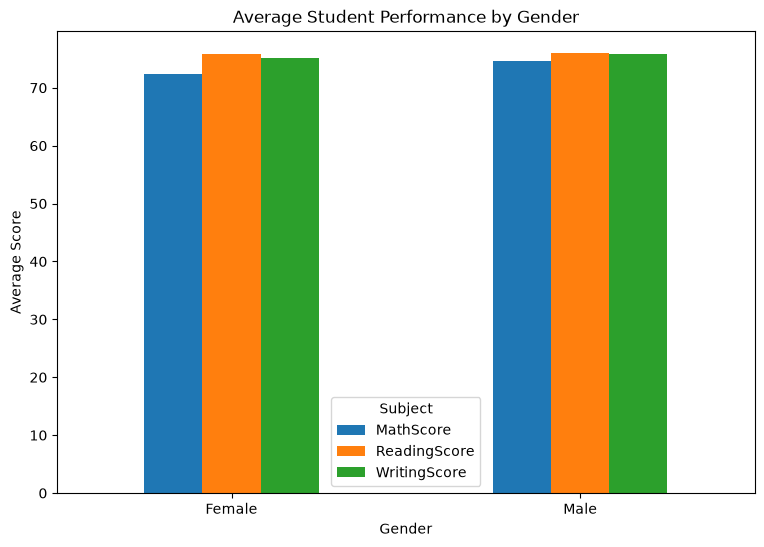

In [50]:
# Calculate mean scores by gender
gender_scores = df.groupby("Gender")[
    ["MathScore", "ReadingScore", "WritingScore"]
].mean()

print("Average Scores by Gender:")
print(gender_scores)

# Grouped bar chart
gender_scores.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Average Student Performance by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")

plt.show()

- Examine the effect of parental education on student scores by creating box plots for Math, Reading, and Writing grouped by parental education levels.

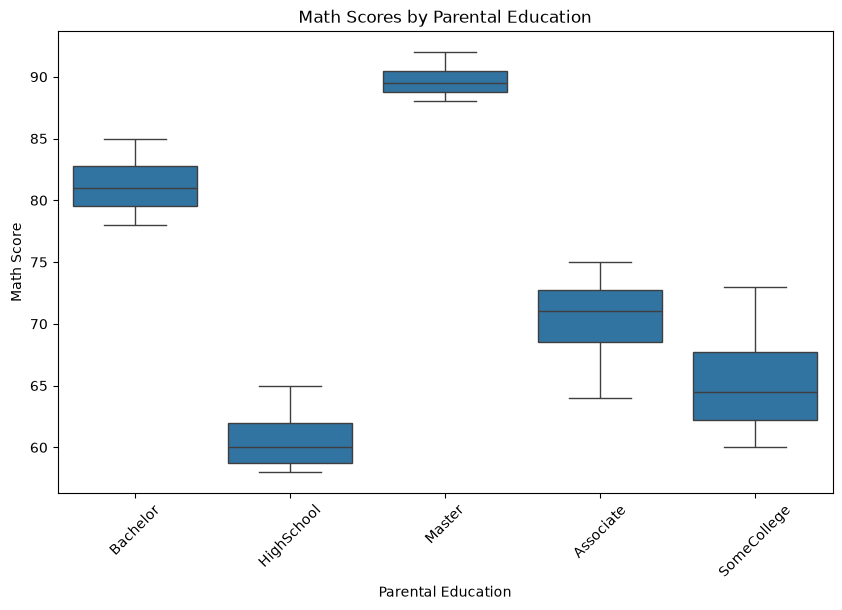

In [52]:
#Math score
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="ParentalEducation",
    y="MathScore"
)

plt.title("Math Scores by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Math Score")
plt.xticks(rotation=45)

plt.show()

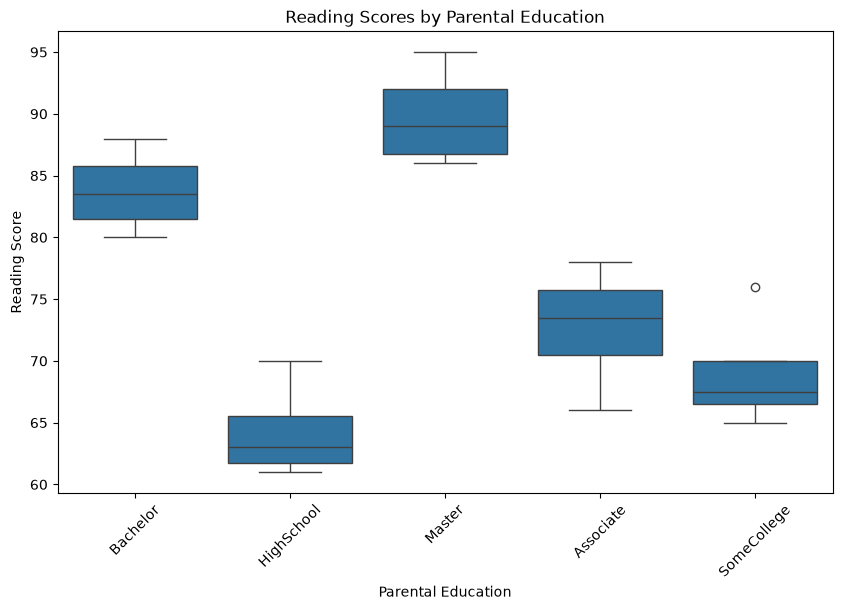

In [53]:
#Reading Score
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="ParentalEducation",
    y="ReadingScore"
)

plt.title("Reading Scores by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Reading Score")
plt.xticks(rotation=45)

plt.show()

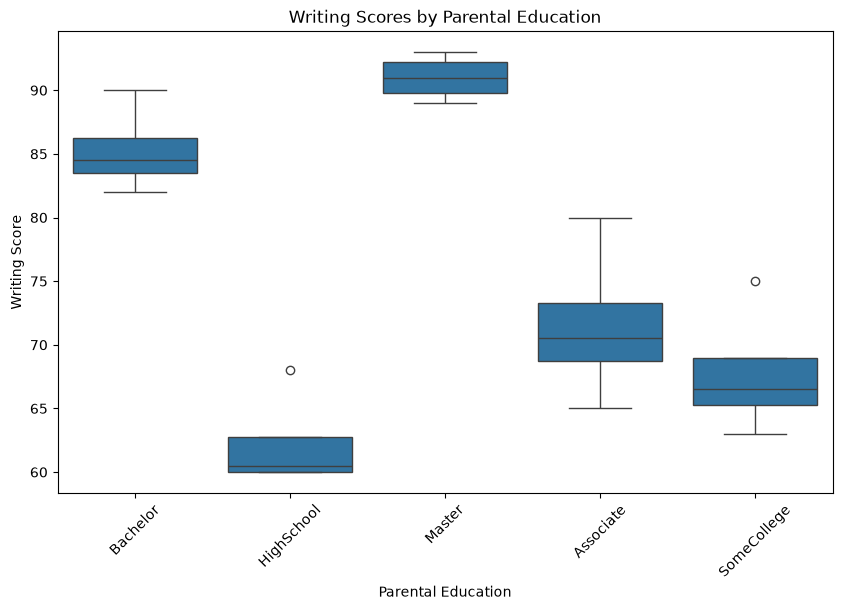

In [54]:
#Writing Score
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="ParentalEducation",
    y="WritingScore"
)

plt.title("Writing Scores by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Writing Score")
plt.xticks(rotation=45)

plt.show()

#### iii. Impact of Lunch Type on Academic Performance

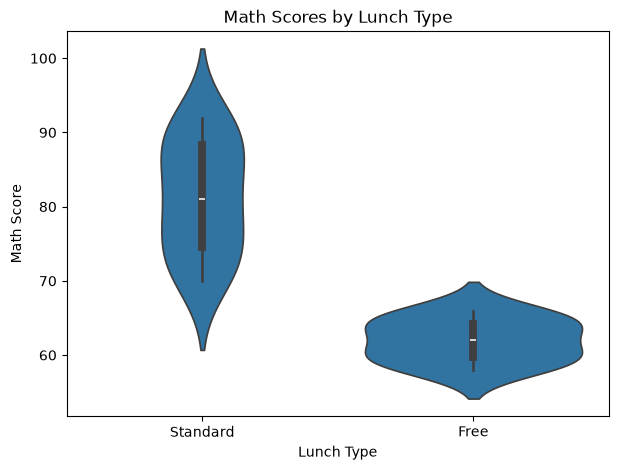

In [55]:
plt.figure(figsize=(7, 5))

sns.violinplot(
    data=df,
    x="Lunch",
    y="MathScore"
)

plt.title("Math Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Math Score")

plt.show()

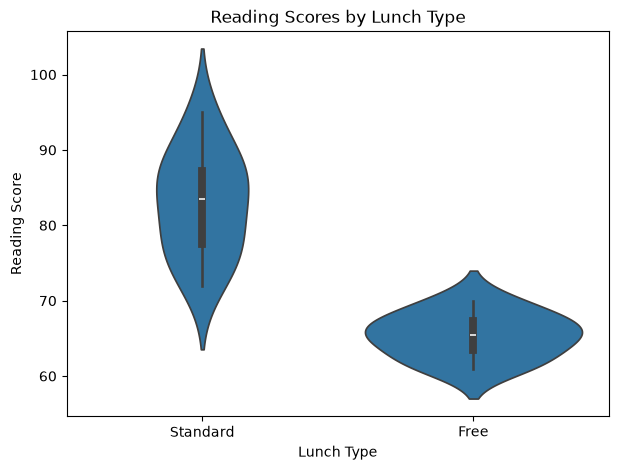

In [56]:
plt.figure(figsize=(7, 5))

sns.violinplot(
    data=df,
    x="Lunch",
    y="ReadingScore"
)

plt.title("Reading Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Reading Score")

plt.show()

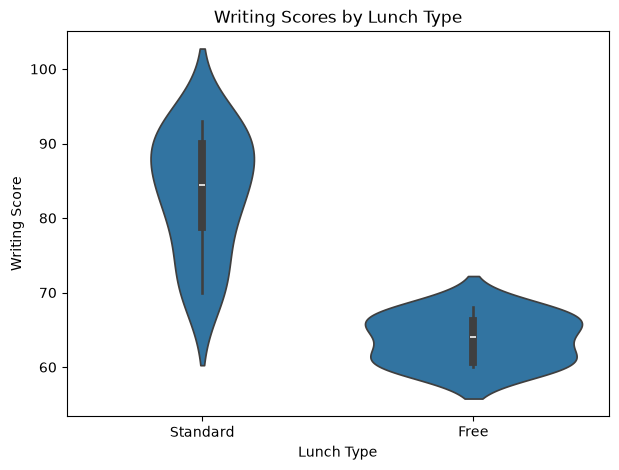

In [57]:
plt.figure(figsize=(7, 5))

sns.violinplot(
    data=df,
    x="Lunch",
    y="WritingScore"
)

plt.title("Writing Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Writing Score")

plt.show()

#### iv. Correlation Between Math, Reading, and Writing Correlation Heatmap

Correlation Matrix:
              MathScore  ReadingScore  WritingScore
MathScore      1.000000      0.977538      0.988180
ReadingScore   0.977538      1.000000      0.979242
WritingScore   0.988180      0.979242      1.000000


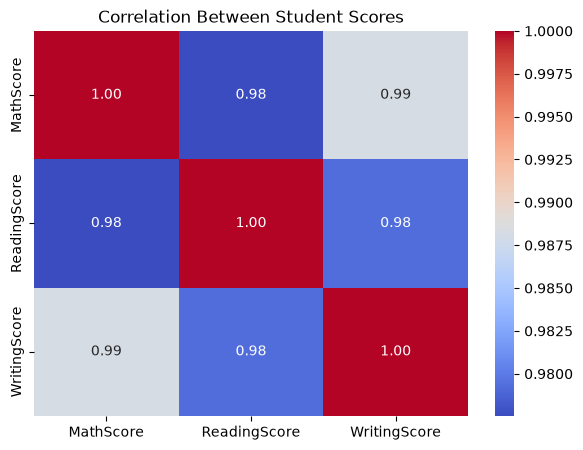

In [58]:
# Select score columns
scores = df[
    ["MathScore", "ReadingScore", "WritingScore"]
]

# Calculate correlation matrix
correlation = scores.corr()

print("Correlation Matrix:")
print(correlation)

# Create heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Student Scores")

plt.show()

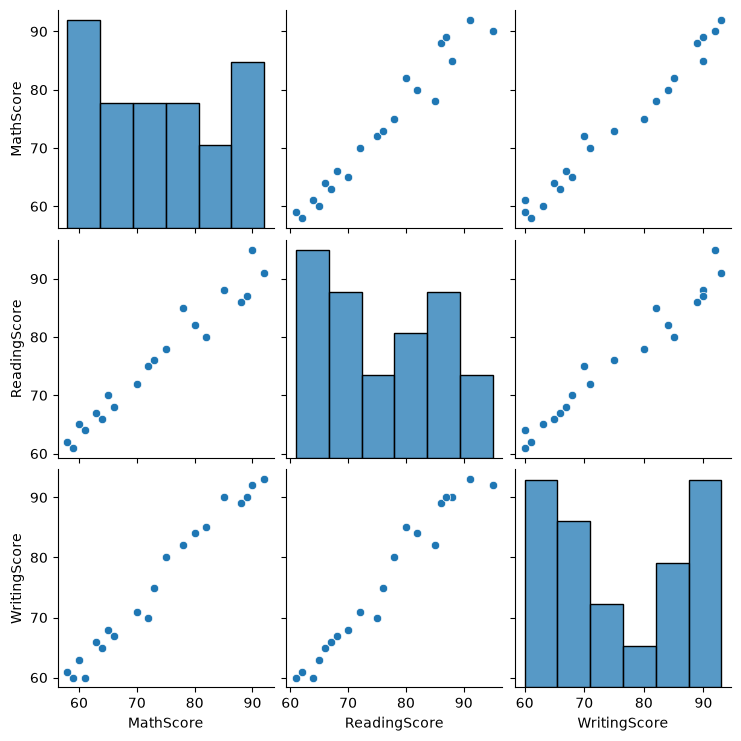

In [59]:
# Pair Plot
sns.pairplot(
    df[
        ["MathScore", "ReadingScore", "WritingScore"]
    ]
)

plt.show()

---

<div align="center">

### Declaration

_I hereby declare that the work submitted in this practical assignment is my own and has not been copied from any other source._

| | |
|---|---|
| **Student Name** |Shahid Momin |
| **PRN** | 125M1H031|
| **Date** |026-08-2026 |

---

**Prof. Prakash Ukhalkar**  
Course Teacher - Advanced Data Science Lab [MCA33PE21]

![](https://img.shields.io/badge/MCA33PE21-Advanced%20Data%20Science%20Lab-blue?style=flat-square)
![](https://img.shields.io/badge/Practical%20Assignment-01-green?style=flat-square)

</div>